# E-Commerce EDA — Key Findings

1. **Category profitability doesn't match revenue** — Electronics leads in 
   revenue, but Clothing has the highest profit margin. Furniture generates 
   solid revenue but has by far the weakest margin.

2. **Revenue is geographically concentrated** — Madhya Pradesh and Maharashtra 
   together account for ~45% of total revenue, far ahead of all other states.

3. **Some states are profit-negative despite generating revenue** — Tamil Nadu, 
   Punjab, Andhra Pradesh, and Bihar show negative total profit. The cause 
   differs by state: Furniture drags down AP and Tamil Nadu, while Electronics 
   drags down Bihar and Punjab.

4. **July 2018 saw a sharp revenue dip**, driven by fewer items per order 
   (not fewer customers). Breaking it down by category vs target shows 
   Clothing (21% of target) and Furniture (32% of target) nearly collapsed, 
   while Electronics held up comparatively well (72%).

In [29]:
import pandas as pd
import sqlalchemy
print("pandas:", pd.__version__)
print("sqlalchemy:", sqlalchemy.__version__)

pandas: 2.3.3
sqlalchemy: 2.0.52


In [30]:
from sqlalchemy import create_engine
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()

username = "postgres"
password = os.getenv("DB_PASSWORD")
host = "localhost"
port = "5432"
database = "ecommerce_dataana"

engine = create_engine(f"postgresql://{username}:{password}@{host}:{port}/{database}")
print("Engine created")

Engine created


In [31]:
orders_df = pd.read_sql("SELECT * FROM list_of_orders", engine)
details_df = pd.read_sql("SELECT * FROM order_details", engine)
target_df = pd.read_sql("SELECT * FROM sales_target", engine)

print(orders_df.shape)
print(details_df.shape)
print(target_df.shape)

(500, 5)
(1500, 7)
(36, 4)


In [32]:
orders_df.info()
print("---")
details_df.info()
print("---")
target_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       500 non-null    object
 1   order_date     500 non-null    object
 2   customer_name  500 non-null    object
 3   state          500 non-null    object
 4   city           500 non-null    object
dtypes: object(5)
memory usage: 19.7+ KB
---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1500 non-null   int64  
 1   order_id           1500 non-null   object 
 2   order_amount       1500 non-null   float64
 3   order_profit       1500 non-null   float64
 4   order_category     1500 non-null   object 
 5   order_quantity     1500 non-null   int64  
 6   order_subcategory  1500 non-null   object 
dtypes: floa

In [33]:
orders_df["order_date"] = pd.to_datetime(orders_df["order_date"])
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       500 non-null    object        
 1   order_date     500 non-null    datetime64[ns]
 2   customer_name  500 non-null    object        
 3   state          500 non-null    object        
 4   city           500 non-null    object        
dtypes: datetime64[ns](1), object(4)
memory usage: 19.7+ KB


In [34]:
#Checks for null explicity
print(orders_df.isnull().sum())
print("---")
print(details_df.isnull().sum())
print("---")
print(target_df.isnull().sum())

order_id         0
order_date       0
customer_name    0
state            0
city             0
dtype: int64
---
id                   0
order_id             0
order_amount         0
order_profit         0
order_category       0
order_quantity       0
order_subcategory    0
dtype: int64
---
id                0
order_month       0
order_category    0
sales_target      0
dtype: int64


Clean — zero nulls across all three tables, in every colum, (the dropna(how="all") calls) worked, and now we don't have to deal with missing-value imputation before analysis.

In [35]:
#Checking for total revenue and profit from details_df

print("Total_revenue:", details_df['order_amount'].sum())
print("Total_Profit:",details_df['order_profit'].sum())

Total_revenue: 431502.0
Total_Profit: 23955.0


## Revenue vs Profit by Category

Comparing total revenue and profit across product categories reveals whether 
high-revenue categories are actually the most profitable ones.

In [36]:
print('Highest Generated revenue across all product categories:')
print(details_df.groupby("order_category")["order_amount"].sum().sort_values(ascending=False))
print('Highest Generated profit across all product categories:')
print(details_df.groupby("order_category")["order_profit"].sum().sort_values(ascending=False))

Highest Generated revenue across all product categories:
order_category
Electronics    165267.0
Clothing       139054.0
Furniture      127181.0
Name: order_amount, dtype: float64
Highest Generated profit across all product categories:
order_category
Clothing       11163.0
Electronics    10494.0
Furniture       2298.0
Name: order_profit, dtype: float64


## Revenue Trend Over Time

Understanding how revenue changes month by month reveals seasonality, 
growth trends, and any unusual spikes or drops worth investigating.

In [37]:
merged_df = orders_df.merge(details_df, on="order_id", how="left")
print(merged_df.shape)
merged_df.head()

(1500, 11)


,order_id,order_date,customer_name,state,city,id,order_amount,order_profit,order_category,order_quantity,order_subcategory
0,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,1,1275.0,-1148.0,Furniture,7,Bookcases
1,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,2,66.0,-12.0,Clothing,5,Stole
2,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,3,8.0,-2.0,Clothing,3,Hankerchief
3,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,4,80.0,-56.0,Electronics,4,Electronic Games
4,B-25602,2018-04-01,Pearl,Maharashtra,Pune,5,168.0,-111.0,Electronics,2,Phones


In [38]:
merged_df["order_month"] = merged_df["order_date"].dt.to_period("M")
monthly_revenue = merged_df.groupby("order_month")["order_amount"].sum()
monthly_revenue

order_month
2018-04    32726.0
2018-05    28545.0
2018-06    23658.0
2018-07    12966.0
2018-08    30899.0
2018-09    26628.0
2018-10    31615.0
2018-11    48086.0
2018-12    37579.0
2019-01    61439.0
2019-02    38424.0
2019-03    58937.0
Freq: M, Name: order_amount, dtype: float64

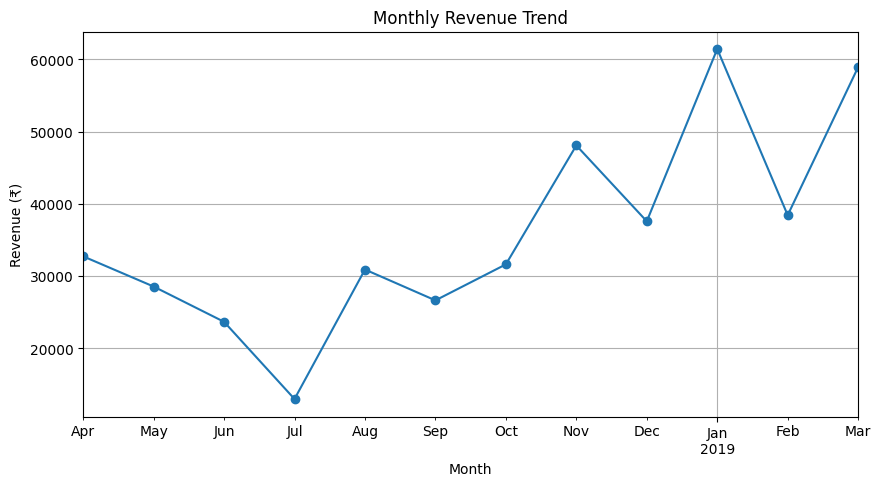

In [39]:
import matplotlib.pyplot as plt

monthly_revenue.plot(kind="line", marker="o", figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.grid(True)
plt.show()



Revenue dropped sharply in **July 2018** (~₹13K, the lowest point in the dataset), 
after averaging ~₹30K in the prior months. It recovered immediately in August 
and stayed in the ₹25K-30K range for a few months, then climbed steadily 
from November onward, peaking at **~₹61K in January 2019** — the highest 
revenue month in the entire dataset.

**Next question:** what caused the July dip? Was it fewer orders, lower-value 
orders, or a specific category underperforming that month?

## Investigating the July 2018 Dip

Was July's low revenue due to fewer orders, or lower average order value?

In [40]:
july_orders = merged_df[merged_df["order_month"] == "2018-07"]["order_id"].nunique()
june_orders = merged_df[merged_df["order_month"] == "2018-06"]["order_id"].nunique()

print("July 2018 unique orders:", july_orders)
print("June 2018 unique orders:", june_orders)

July 2018 unique orders: 31
June 2018 unique orders: 30


In [41]:
july_avg = merged_df[merged_df["order_month"] == "2018-07"]["order_amount"].mean()
june_avg = merged_df[merged_df["order_month"] == "2018-06"]["order_amount"].mean()

print("July avg order value:", july_avg)
print("June avg order value:", june_avg)

July avg order value: 202.59375
June avg order value: 234.23762376237624


Quick gap-check
June avg: ₹234
July avg: ₹203
Difference: about 13% lower per item in July

That's a real dip, but is it enough to explain the huge revenue drop we saw (₹23,658 in June vs just ₹12,966 in July — nearly 45% lower)? A 13% drop in average value doesn't fully explain a 45% drop in total revenue on its own.

In [42]:
july_items = merged_df[merged_df["order_month"] == "2018-07"].shape[0]
june_items = merged_df[merged_df["order_month"] == "2018-06"].shape[0]

print("July items sold:", july_items)
print("June items sold:", june_items)

July items sold: 64
June items sold: 101


## Root Cause: July 2018 Revenue Dip

- Order count was stable (31 vs 30 in June) — the drop wasn't about fewer customers
- Items sold dropped sharply: 64 in July vs 101 in June (~37% fewer)
- Average item value also dipped slightly (₹203 vs ₹234, ~13% lower)

**Conclusion:** the July dip was driven primarily by smaller basket sizes 
(fewer items per order), not fewer orders or a pricing issue. This suggests 
a seasonal or promotional effect rather than a customer acquisition problem.

## ____________

## Revenue by State

Which states generate the most revenue? This is useful context for the 
geography view we'll eventually build in Power BI.

In [43]:
highest_state_revenue = merged_df.groupby("state")["order_amount"].sum().sort_values(ascending=False)
highest_state_revenue

state
Madhya Pradesh       105140.0
Maharashtra           95348.0
Delhi                 22531.0
Uttar Pradesh         22359.0
Rajasthan             21149.0
Gujarat               21058.0
Punjab                16786.0
Karnataka             15058.0
West Bengal           14086.0
Kerala                13459.0
Andhra Pradesh        13256.0
Bihar                 12943.0
Nagaland              11903.0
Jammu and Kashmir     10829.0
Haryana                8863.0
Himachal Pradesh       8666.0
Goa                    6705.0
Tamil Nadu             6087.0
Sikkim                 5276.0
Name: order_amount, dtype: float64

## Finding: Revenue Is Highly Concentrated in Two States

Madhya Pradesh (₹1,05,140) and Maharashtra (₹95,348) together account for 
nearly 45% of total revenue — dramatically ahead of every other state. 
Delhi, the next closest, generates less than a quarter of Maharashtra's revenue.

This concentration raises a strategic question: is this reach limited to 
a couple of strong markets, or an opportunity to expand into underserved 
states with similar potential?

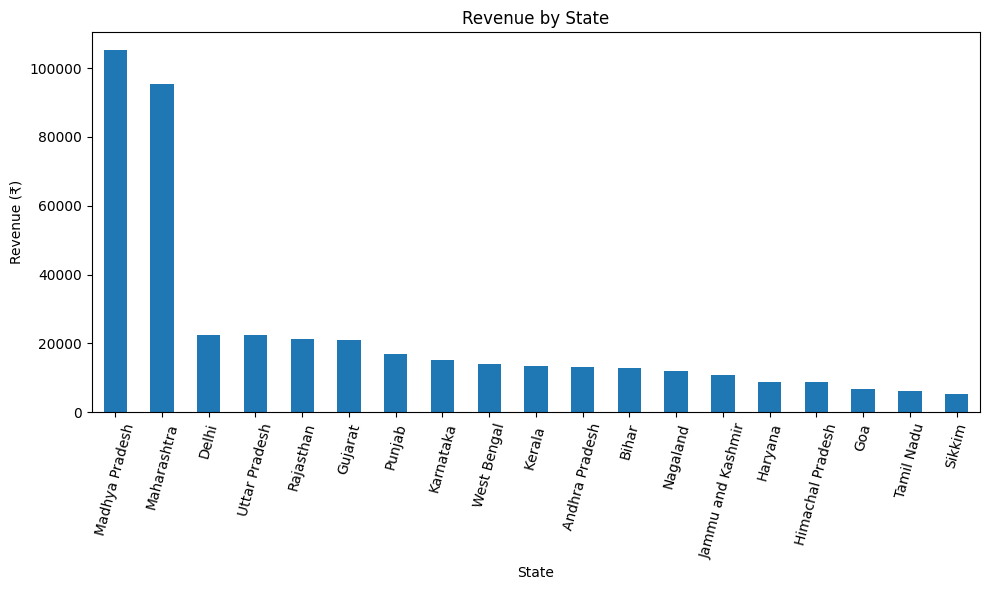

In [44]:
plt.figure(figsize=(10,6))
highest_state_revenue.plot(kind="bar")
plt.title("Revenue by State")
plt.xlabel("State")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [45]:
highest_state_profit = merged_df.groupby("state")["order_profit"].sum().sort_values(ascending=False)
highest_state_profit

state
Maharashtra          6176.0
Madhya Pradesh       5551.0
Uttar Pradesh        3237.0
Delhi                2987.0
West Bengal          2500.0
Kerala               1871.0
Haryana              1325.0
Rajasthan            1257.0
Himachal Pradesh      656.0
Karnataka             645.0
Gujarat               465.0
Sikkim                401.0
Goa                   370.0
Nagaland              148.0
Jammu and Kashmir       8.0
Bihar                -321.0
Andhra Pradesh       -496.0
Punjab               -609.0
Tamil Nadu          -2216.0
Name: order_profit, dtype: float64

## Finding: Some States Are Revenue-Positive but Profit-Negative

While Maharashtra and Madhya Pradesh lead in both revenue and profit, four 
states — Tamil Nadu, Punjab, Andhra Pradesh, and Bihar — show **negative 
total profit** despite generating real revenue. Tamil Nadu is the worst 
performer (-₹2,216), losing money at nearly 4x the rate of the next-worst state.

This suggests these markets may have high discounting, higher return rates, 
or logistics/delivery costs eating into margins — worth investigating further 
(e.g. by category) before any regional strategy decisions.

In [46]:
loss_states = ["Tamil Nadu", "Punjab", "Andhra Pradesh", "Bihar"]

state_category_profit = merged_df[merged_df["state"].isin(loss_states)].groupby(["state", "order_category"])["order_profit"].sum()
state_category_profit

state           order_category
Andhra Pradesh  Clothing           596.0
                Electronics        476.0
                Furniture        -1568.0
Bihar           Clothing             1.0
                Electronics       -814.0
                Furniture          492.0
Punjab          Clothing          1452.0
                Electronics      -2132.0
                Furniture           71.0
Tamil Nadu      Clothing           -98.0
                Electronics        369.0
                Furniture        -2487.0
Name: order_profit, dtype: float64

## Finding: Losses Are Category-Specific, Not Uniform

The four loss-making states don't share a single cause:
- **Furniture** drives losses in Andhra Pradesh (-₹1,568) and Tamil Nadu (-₹2,487)
- **Electronics** drives losses in Bihar (-₹814) and Punjab (-₹2,132)
- **Clothing is profitable in 3 of 4 states** — it's not part of the problem

This aligns with the earlier category-level finding that Furniture has the 
lowest profit margin overall — its weak margins compound into real losses 
in specific states. A targeted fix (better Furniture pricing/logistics in 
AP and Tamil Nadu, and Electronics discounting review in Bihar and Punjab) 
would likely be more effective than a blanket regional strategy change.

**_______________**

## Actual Sales vs Target

Comparing actual monthly revenue by category against the sales targets 
set in `sales_target` reveals whether categories are over- or under-performing 
against expectations.

In [47]:
print(target_df['order_month'].head())

0    Apr-18
1    May-18
2    Jun-18
3    Jul-18
4    Aug-18
Name: order_month, dtype: object


In [48]:
target_df["order_month"] = pd.to_datetime(target_df["order_month"], format="%b-%y").dt.to_period("M")
target_df["order_month"].head()

0    2018-04
1    2018-05
2    2018-06
3    2018-07
4    2018-08
Name: order_month, dtype: period[M]

In [49]:
actual_by_month_category = merged_df.groupby(["order_month", "order_category"])["order_amount"].sum().reset_index()
actual_by_month_category.head()

,order_month,order_category,order_amount
0,2018-04,Clothing,13478.0
1,2018-04,Electronics,11127.0
2,2018-04,Furniture,8121.0
3,2018-05,Clothing,9518.0
4,2018-05,Electronics,12807.0


In [50]:
comparison = actual_by_month_category.merge(
    target_df,
    on=["order_month", "order_category"],
    how="left"
)
comparison["performance_%"] = (comparison["order_amount"] / comparison["sales_target"]) * 100
comparison.head(10)

,order_month,order_category,order_amount,id,sales_target,performance_%
0,2018-04,Clothing,13478.0,13,12000.0,112.316667
1,2018-04,Electronics,11127.0,25,9000.0,123.633333
2,2018-04,Furniture,8121.0,1,10400.0,78.086538
3,2018-05,Clothing,9518.0,14,12000.0,79.316667
4,2018-05,Electronics,12807.0,26,9000.0,142.300000
5,2018-05,Furniture,6220.0,2,10500.0,59.238095
6,2018-06,Clothing,8782.0,15,12000.0,73.183333
7,2018-06,Electronics,9344.0,27,9000.0,103.822222
8,2018-06,Furniture,5532.0,3,10600.0,52.188679
9,2018-07,Clothing,2981.0,16,14000.0,21.292857


That means **Clothing** only hit **21%** of its target in **July 2018** missed by nearly **79%** (100% - 21% = 79% shortfall). That's a massive miss, not a moderate one. This is a much bigger deal than **"some missed by 50%"** — this is the most extreme underperformance in the table so far.

**And this connects directly to the earlier finding!**

We already discovered July 2018 had an overall revenue dip, driven by fewer items per order. Now we're seeing why, at the category level: Clothing specifically collapsed in July (21% of target), which likely explains a big chunk of that month's dip.

&&Let's verify — check the other categories in July 2018 too*

we've only seen Clothing's July row so far. lets filter to see Electronics and Furniture's July performance:

In [51]:
comparison[comparison["order_month"] == "2018-07"]

,order_month,order_category,order_amount,id,sales_target,performance_%
9,2018-07,Clothing,2981.0,16,14000.0,21.292857
10,2018-07,Electronics,6502.0,28,9000.0,72.244444
11,2018-07,Furniture,3483.0,4,10800.0,32.250000


**This completes the analytical chain**
Overall revenue dipped sharply in July 2018
Root cause: driven by fewer items per order, not fewer customers
Now: the dip wasn't evenly spread — Clothing and Furniture nearly collapsed against target, while Electronics only dipped moderately

## Finding: July 2018 Dip Was Driven by Clothing & Furniture Collapse

Breaking the July revenue dip down by category against target reveals it 
wasn't uniform:
- **Clothing**: only 21.3% of target (₹2,981 vs ₹14,000) — catastrophic
- **Furniture**: only 32.3% of target (₹3,483 vs ₹10,800) — severe
- **Electronics**: 72.2% of target — a moderate miss, held up comparatively well

This suggests something specific disrupted Clothing and Furniture sales in 
July 2018 (e.g. seasonal demand, stock issues, or a paused promotion) rather 
than a broad market-wide slowdown, since Electronics remained relatively stable.